<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/DensityBased.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv('Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

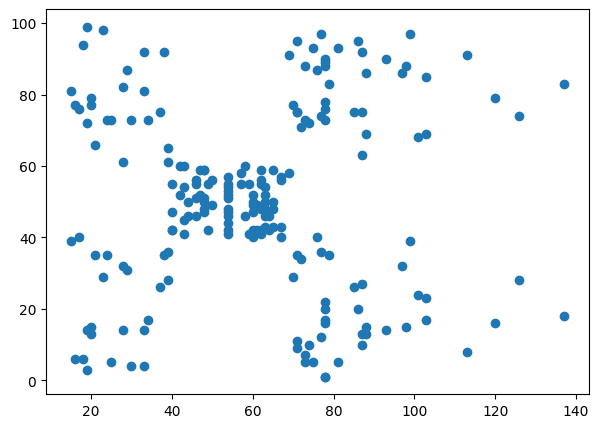

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
dbscan = DBSCAN(eps=3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [ ]:
import pandas as pd

X = pd.DataFrame(
    X,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)


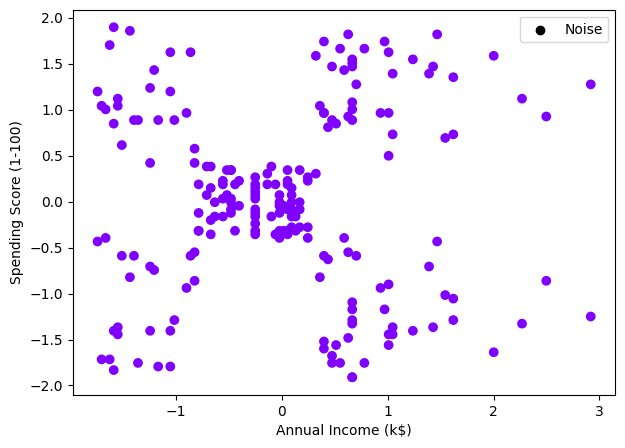

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=clusters,
    cmap='rainbow'
)

plt.scatter(
    X.iloc[clusters == -1]['Annual Income (k$)'],
    X.iloc[clusters == -1]['Spending Score (1-100)'],
    color='black',
    label='Noise'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [ ]:
eps_values = [0.2,0.3,0.5]
for eps in eps_values:
  print(f"\n Evaluting DBSCAN using eps={eps}")
  dbscan = DBSCAN(eps=eps, min_samples=5)
  labels = dbscan.fit_predict(X_scaled)
  unique_labels = set(labels)
  n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
  n_noise = list(labels).count(-1)
  noise_ratio = n_noise / len(labels)
  print(f"Number of clusters: {n_clusters}")
  print(f"Number of Noise points : ", round(noise_ratio,2))
  if n_clusters > 1:
    X_non_noise = X[labels != -1]
    labels_non_noise = labels[labels != -1]
    sc = StandardScaler()
    X_scaled_non_noise = sc.fit_transform(X_non_noise)




 Evaluting DBSCAN using eps=0.2
Number of clusters: 7
Number of Noise points :  0.39

 Evaluting DBSCAN using eps=0.3
Number of clusters: 7
Number of Noise points :  0.17

 Evaluting DBSCAN using eps=0.5
Number of clusters: 2
Number of Noise points :  0.04
